<center><image src="https://drive.google.com/uc?id=1n3G4TdK_u6PQHcLrxB_A0HijNdigXmUH">

<h3 style="text-align: center;"><b>Школа глубокого обучения ФПМИ МФТИ</b></h3>

<h3 style="text-align: center;"><b>Домашнее задание. Классификация звуков</b></h3>

**Автор**: Ермекова Асель


В этом задании вам предстоит решить задачу классификации звуков на основе wav файлов и использовании различных аугментаций данных.

Есть две части этого домашнего задания.

### 1 Часть. Отправить ваши предсказания в Stepik.
Результат вашей лучшей модели будет оцениваться на тестовой выборке по метрике Accuracy. Эта часть оценивается до 5 баллов.

1) $1.00 \geqslant score \geqslant 0.75$ --- 5 баллов

2) $0.75 > score \geqslant 0.70$ --- 4 балла

3) $0.70 > score \geqslant 0.60$ --- 3 балла

4) $0.60 > score \geqslant 0.50$ --- 2 балла

5) $0.50 > score \geqslant 0.25$ --- 1 балл

6) $0.25 > score$ --- 0 баллов

Для этого мы предварительно разделили данные в задании на три части.

1. `train.csv`. На этом наборе данных вам необходимо создать и обучить модель.
2. `valid.csv`. На этом наборе данных вы можете валидировать вашу модель.
3. `test.csv`. Предсказания для этого набора необходимо записать в файл `submission.csv` и сдать в соответствующий шаг на Stepik. Количество попыток ограничено до 100 штук. В конце ноутбука есть пример оформления файла посылки.

### 2 Часть. Сделать полноценный отчет о вашей работе (5 баллов).
Опишите итеративный процесс улучшения метрики:
* как вы обработали данные, какие аугментации добавляли, что сработало, а что нет.
* какие архитектуры модели попробовали и какие результаты получились.

В этом пункте вам необходимо отправить файл в формате .ipynb на Stepik --- для этого в домашнем задании есть отдельный шаг. Этот пункт оценивается до 5 баллов.

### Peer-review
Вторая часть будет проверяться в формате peer-review, т.е. вашу посылку на Stepik будут проверять 3 других студента, и медианное значение их оценок будет выставлено. Чтобы получить баллы, вам также нужно будет проверить трех других учеников. Это станет доступно после того, как вы сдадите задание сами.


### Несколько замечаний по выполнению работы
* Во всех пунктах указания это минимальный набор вещей, которые стоит сделать. Если вы можете сделать какой-то шаг лучше или добавить что-то свое --- дерзайте!
* Пожалуйста, перед сдачей ноутбука убедитесь, что работа чистая и понятная. Это значительно облегчит проверку и повысит ваши ожидаемые баллы.
* Если у вас будут проблемы с решением или хочется совета, то пишите в наш чат в телеграме.


# **Environmental Sound Classification**

## **Task Overview**

В этом домашнем задании вам предстоит работать с датасетом различных звуков окружающей среды (собака, дождь, плач ребёнка и т. д.).

### **Part 1: Create Dataset**

Первым делом давайте скачаем датасет и прилагающие csv файлы с метками класса.

In [1]:
!gdown 1TQa-tOX1b8QxuXBcrYrTveVAwfw1XBPO # sound_classification_dataset.zip
!gdown 1BvUhnTeOvik0NeuJtMrfr7LXpHCU1DUT # train.csv
!gdown 1my0RPDQdTxvCGmnZei06tiXgKko3R4o4 # valid.csv
!gdown 1Z6BG52Tmyjxhen7DqvO59Rlz-2pAg7ks # test.csv

Downloading...
From (original): https://drive.google.com/uc?id=1TQa-tOX1b8QxuXBcrYrTveVAwfw1XBPO
From (redirected): https://drive.google.com/uc?id=1TQa-tOX1b8QxuXBcrYrTveVAwfw1XBPO&confirm=t&uuid=b5a20448-cc02-4974-b40f-b081e680b30d
To: /content/sound_classification_dataset.zip
100% 645M/645M [00:02<00:00, 267MB/s]
Downloading...
From: https://drive.google.com/uc?id=1BvUhnTeOvik0NeuJtMrfr7LXpHCU1DUT
To: /content/train.csv
100% 3.09k/3.09k [00:00<00:00, 13.2MB/s]
Downloading...
From: https://drive.google.com/uc?id=1my0RPDQdTxvCGmnZei06tiXgKko3R4o4
To: /content/valid.csv
100% 1.06k/1.06k [00:00<00:00, 6.39MB/s]
Downloading...
From: https://drive.google.com/uc?id=1Z6BG52Tmyjxhen7DqvO59Rlz-2pAg7ks
To: /content/test.csv
100% 719/719 [00:00<00:00, 4.36MB/s]


Разархивируйте zip файл, где содержатся wav файлы датасета.

In [2]:
!unzip /content/sound_classification_dataset.zip

Archive:  /content/sound_classification_dataset.zip
   creating: content/sound_classification_dataset/
  inflating: content/sound_classification_dataset/1-61261-A-44.wav  
  inflating: content/sound_classification_dataset/2-104105-A-19.wav  
  inflating: content/sound_classification_dataset/3-150363-A-38.wav  
  inflating: content/sound_classification_dataset/1-18074-A-6.wav  
  inflating: content/sound_classification_dataset/5-161270-A-33.wav  
  inflating: content/sound_classification_dataset/5-221529-A-39.wav  
  inflating: content/sound_classification_dataset/2-61618-A-46.wav  
  inflating: content/sound_classification_dataset/1-46274-A-18.wav  
  inflating: content/sound_classification_dataset/1-69760-A-16.wav  
  inflating: content/sound_classification_dataset/2-64963-A-15.wav  
  inflating: content/sound_classification_dataset/2-108766-A-9.wav  
  inflating: content/sound_classification_dataset/4-165845-A-45.wav  
  inflating: content/sound_classification_dataset/5-235644-A-30.w

С помощью этой либы будем делать аугментации

In [3]:
!pip install torch_audiomentations

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.6/59.6 kB 5.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.5/48.5 kB 4.8 MB/s eta 0:00:00
  Created wheel for julius: filename=julius-0.2.7-py3-none-any.whl size=21870 sha256=d9460e5bf9431a1adad7971940c21f1ab15a1edc2254f890476c825e87df1792
  Stored in directory: /root/.cache/pip/wheels/de/c1/ca/544dafe48401e8e2e17064dfe465a390fca9e8720ffa12e744
Successfully built julius


In [4]:
import pandas as pd
import librosa
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Audio
import random
import glob
import warnings
warnings.filterwarnings("ignore")

In [5]:
train_df = pd.read_csv("train.csv")
valid_df = pd.read_csv("valid.csv")
test_df = pd.read_csv("test.csv")

In [6]:
train_df.shape, valid_df.shape, test_df.shape

((120, 2), (40, 2), (40, 1))

Довольно маленькая тренировочная выборка

In [7]:
train_df.category.value_counts()

,count
category,
dog,24
rain,24
crying_baby,24
clock_tick,24
sneezing,24


Всего 5 классов, дисбаланса нет.

Послушаем, что в тренирвоочной выборке

In [9]:
train_df["path"] = "/content/content/sound_classification_dataset/" + train_df["filename"]
valid_df["path"] = "/content/content/sound_classification_dataset/" + valid_df["filename"]
test_df["path"] = "/content/content/sound_classification_dataset/" + test_df["filename"]

In [10]:
path = "/content/content/sound_classification_dataset/*.wav"
all_files = glob.glob(path)

In [11]:
train_files = [x for x in all_files if x.split("/")[-1] in train_df["filename"].tolist()]
valid_files = [x for x in all_files if x.split("/")[-1] in valid_df["filename"].tolist()]
test_files = [x for x in all_files if x.split("/")[-1] in test_df["filename"].tolist()]

In [12]:
def display_random_audio(files):
  random_wav = random.choice(files)
  wav, sr = librosa.load(random_wav)
  display(Audio(data=wav, rate=sr))

In [13]:
display_random_audio(train_files)

In [14]:
display_random_audio(valid_files)

In [15]:
display_random_audio(test_files)

Название класса соответсвует аудио.

Закодируем наши лейблы, иначе будут ошибки из-за str

In [155]:
from sklearn.preprocessing import LabelEncoder

enc = LabelEncoder()
enc.fit(train_df["category"]);
train_df["category"] = enc.transform(train_df["category"])
valid_df["category"] = enc.transform(valid_df["category"])

Колонка filename нам не нужна будет, удалим ее

In [31]:
train_df = train_df.drop(["filename"], axis=1)
valid_df = valid_df.drop(["filename"], axis=1)
test_df = test_df.drop(["filename"], axis=1)

Для этого задания при создании датасета вам нужно сделать обработку аудио данных следующим образом:
* **Sample rate --> 16000**: ресэмплируйте оригинальный `sample_rate` в `sample_rate = 16000`
* **Stereo --> Mono**: преобразуйте многоканальное аудио в моноканальное
* **Length = X secs:** чтобы суметь создать батч, вам необходимо, чтобы длина всех ваших аудиозаписей была одинаковой, поэтому вам нужно зафиксировать длину всех аудиозаписей, и если аудио меньше заданной длины, то сделайте паддинг, если больше, обрежьте аудио до заданной длины.

* **Audio Augmentation:** используйте разные аугментации. Вы можете воспользоваться библиотеками:
  * [torchaudio.transforms](https://docs.pytorch.org/audio/main/transforms.html)
  * [torch_audiomentations](https://github.com/iver56/torch-audiomentations)

**ВАЖНО**: в этом домашнем задании вам нельзя переводить `wav` в мелспектрограммы.

Внизу для удобства предоставлен псевдокод, который можно заполнить необходимыми функциями, но вы можете видоизменять его как вам будет удобно.

Для аугментаций воспользуемся [https://github.com/iver56/torch-audiomentations](torch_audiomentations)

In [143]:
import torch
import torchaudio
import torch.nn.functional as F
from torch_audiomentations import Compose, AddColoredNoise, Gain, PolarityInversion, Shift
from torch.utils.data import Dataset
import pandas as pd
import os

class SimpleAudioDataset(Dataset):
    """A dataset to load, preprocess, and augment audio files."""

    def __init__(self,
                 df,
                 audio_column: str = "path",
                 label_column: str = "category",
                 duration: float = 5.0,
                 mono: bool = True,
                 target_sr: int = 16_000,
                 do_augmentation: bool = True):

        super().__init__()
        self.df = df
        self.audio_column = audio_column
        self.label_column = label_column
        self.duration = duration
        self.mono = mono
        self.target_sr = target_sr
        self.target_len = int(round(duration * target_sr))
        self.do_augmentation = do_augmentation
        self._augmented_data = None

    def __len__(self):

        return len(self.df)

    def __getitem__(self, index):
        # 1. Get the file path and label
        row = self.df.iloc[index] if hasattr(self.df, "iloc") else self.df[index]
        audio_file_path = row[self.audio_column]

        # 2. LOAD: Load the raw audio file
        wav, sr = torchaudio.load(audio_file_path)
        if wav.dtype != torch.float32:
            wav = wav.float()

        # 3. PREPROCESS: Apply the preprocessing steps
        wav = self._resample(wav, sr) # Resample to the sample rate 16000
        wav = self._stereo_to_mono(wav) # Converts (channels, samples) -> (samples,)
        wav = self._cut_or_pad(wav) # State fixed length

        # 4. AUGMENT: Apply augmentations only if training
        if self.do_augmentation:
            wav = self._augmentation(wav)

        wav = wav.squeeze(1)

        # 5. RETURN: We now have a clean, standardized waveform and its label
        if self.label_column is not None:
            return wav, row[self.label_column]
        else:
            return wav

    # --- The Core Preprocessing Functions ---
    def _resample(self, signal, original_sr):
        if original_sr == self.target_sr:
            return signal

        return torchaudio.functional.resample(
            signal, orig_freq=original_sr, new_freq=self.target_sr
            )

    def _stereo_to_mono(self, signal):
        if self.mono:
            if signal.size(0) > 1:
              signal = signal.mean(dim=0, keepdim=True)
            else:
                pass
        return signal

    def _cut_or_pad(self, signal):
        if signal.size(-1) == self.target_len:
            return signal
        elif signal.size(-1) > self.target_len:
          # обрезаем случайным образом
            start = torch.randint(0, signal.size(-1) - self.target_len + 1, (1,)).item()
            return signal[:, start:start + self.target_len]
        else:
          # паддинг
            pad = self.target_len - signal.size(-1)
            return F.pad(signal, (0, pad))

    def _augmentation(self, signal):
        augment_raw_audio = Compose(
                transforms=[
                    PolarityInversion(p=0.2),
                    Gain(min_gain_in_db=-6.0, max_gain_in_db=6.0, p=0.6),
                    AddColoredNoise(min_snr_in_db=10.0, max_snr_in_db=30.0, p=0.5),
                    Shift(min_shift=-0.1, max_shift=0.1, p=0.5, rollover=True),
                ]
            )
        signal = augment_raw_audio(signal.unsqueeze(0), sample_rate=self.target_sr).squeeze(0)

        return signal

* Polarity inversion - cимуляция ошибок фазы (полезно для робастности)
* Gain - имитация различной громкости записи
* Add noise - шум
* Time shift - смещаем по времени

Преобразуем батч с помощью collate

In [144]:
def collate(batch):
    xs, ys = zip(*batch)
    X = torch.stack(xs, dim=0)
    y = torch.tensor(ys, dtype=torch.long)
    return X, y

In [145]:
train_dataset = SimpleAudioDataset(train_df)
valid_dataset = SimpleAudioDataset(valid_df)

### **Part 2: Building a Model that Learns from Waveforms**

В этом разделе вам нужно написать архитектуру по вашему выбору, которая будет решать задачу классификации на 5 классов.

Решила остановиться на простой модели - 1D CNN.
Тут только свёртки по времени, BatchNorm, ReLU, даунсэмплинг страйдом и глобальный average-pool по времени.

В теории, можно было попробовать attention, но времени не хватило.

In [146]:
import torch.nn as nn

class SoundClassificatonModel(nn.Module):
    """A simple model that processes raw waveforms."""
    def __init__(self, input_size=16000, num_classes=5, in_ch=1, base=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(in_ch, base, kernel_size=11, stride=2, padding=5, bias=False),
            nn.BatchNorm1d(base),
            nn.ReLU(inplace=True),

            nn.Conv1d(base, base*2, kernel_size=9, stride=2, padding=4, bias=False),
            nn.BatchNorm1d(base*2),
            nn.ReLU(inplace=True),

            nn.Conv1d(base*2, base*2, kernel_size=7, stride=2, padding=3, bias=False),
            nn.BatchNorm1d(base*2),
            nn.ReLU(inplace=True),

            nn.Conv1d(base*2, base*4, kernel_size=5, stride=2, padding=2, bias=False),
            nn.BatchNorm1d(base*4),
            nn.ReLU(inplace=True),

            nn.Conv1d(base*4, base*4, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm1d(base*4),
            nn.ReLU(inplace=True),
        )

        # глобальный average pooling
        self.pool = nn.AdaptiveAvgPool1d(1)

        self.head = nn.Sequential(
            nn.Dropout(0.2),
            nn.Linear(base*4, num_classes)
        )

    def forward(self, x):

        x = self.net(x)
        x = self.pool(x).squeeze(-1)
        x = self.head(x)
        return x

### **Part 3: Training and Evaluation**

В этом разделе вам нужно написать код тренировки и запустить саму тренировку и вывести лучшие значения метрики качества на train и valid данных. Для вашего удобства написана функция отображения значений лоссов и метрики accuracy.

In [147]:
def plot_metrics(train_losses, train_accuracies, test_losses, test_accuracies):
    """
    Plot training and validation metrics
    """
    epochs = range(1, len(train_losses) + 1)

    # Create subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # Plot loss
    ax1.plot(epochs, train_losses, 'b-', label='Training Loss', linewidth=2)
    ax1.plot(epochs, test_losses, 'r-', label='Test Loss', linewidth=2)
    ax1.set_title('Training and Test Loss')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Plot accuracy
    ax2.plot(epochs, train_accuracies, 'b-', label='Training Accuracy', linewidth=2)
    ax2.plot(epochs, test_accuracies, 'r-', label='Valid Accuracy', linewidth=2)
    ax2.set_title('Training and Valid Accuracy')
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('Accuracy (%)')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    # Adjust layout and display
    plt.tight_layout()
    plt.show()


В начале создаем датасеты и даталоадеры (train с аугментациями, valid/test без!!!)

Epoch 100/100 | Train Loss: 0.3263 | Train Acc: 90.83% | Valid Loss: 0.4261 | Valid Acc: 82.50%


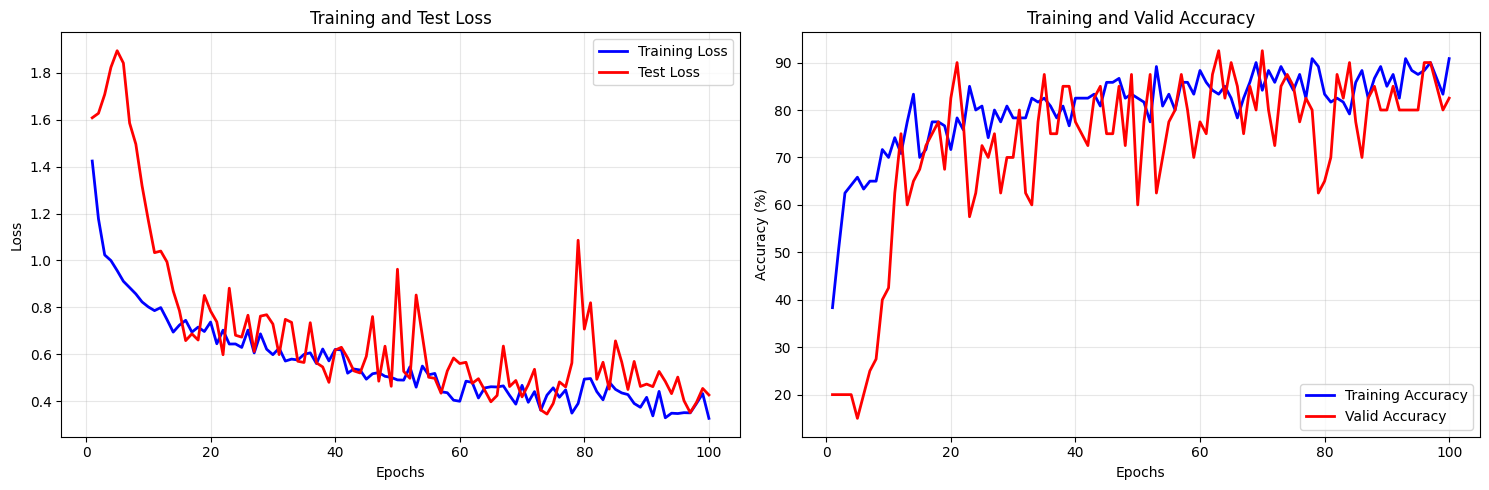


Best Valid Accuracy: 92.50%


In [148]:
from torch.utils.data import DataLoader
from IPython.display import clear_output

TARGET_SR = 16_000
DURATION_SEC = 5.0
BATCH_SIZE = 32
NUM_WORKERS = 4


# Initialize datasets & dataloaders
train_data = SimpleAudioDataset(
    train_df, audio_column="path", label_column="category",
    target_sr=TARGET_SR, duration=DURATION_SEC,
    do_augmentation=True
)
valid_data = SimpleAudioDataset(
    valid_df, audio_column="path", label_column="category",
    target_sr=TARGET_SR, duration=DURATION_SEC,
    do_augmentation=False
)

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True,
                          collate_fn=collate)
valid_loader = DataLoader(valid_data, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True,
                          collate_fn=collate)

# Model, Loss, Optimizer
device = "cuda" if torch.cuda.is_available() else "cpu"
model = SoundClassificatonModel(num_classes=5).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)


train_losses = []
train_accuracies = []
valid_losses = []
valid_accuracies = []

n_epochs = 100
best_valid_acc = 0.0
best_state = None

for epoch in range(1, n_epochs+1):

    # Train
    model.train()
    running_loss, running_correct, running_total = 0.0, 0, 0

    for signals, labels in train_loader:

        # load data to device
        signals, labels = signals.to(device), labels.to(device)

        # Forward pass
        optimizer.zero_grad(set_to_none=True)
        logits = model(signals)
        loss = criterion(logits, labels)

        # Backward pass
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        optimizer.step()

        batch_size = labels.size(0)
        running_loss += loss.item() * batch_size
        running_correct += (logits.argmax(1) == labels).sum().item()
        running_total  += batch_size

    epoch_train_loss = running_loss / max(1, running_total)
    epoch_train_acc  = 100.0 * running_correct / max(1, running_total)

    # Evaluation
    model.eval()
    val_loss_sum, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for signals, labels in valid_loader:
            # load data to device
            signals, labels = signals.to(device), labels.to(device)
            # Forward pass
            logits = model(signals)
            loss = criterion(logits, labels)

            val_loss_sum += loss.item() * labels.size(0)
            val_correct  += (logits.argmax(1) == labels).sum().item()
            val_total    += labels.size(0)

    # Calculate average test loss and accuracy for this epoch
    epoch_valid_loss = val_loss_sum / max(1, val_total)
    epoch_valid_acc  = 100.0 * val_correct / max(1, val_total)

    # Store metrics
    train_losses.append(epoch_train_loss)
    train_accuracies.append(epoch_train_acc)
    valid_losses.append(epoch_valid_loss)
    valid_accuracies.append(epoch_valid_acc)


    clear_output(wait=True)
    print(f"Epoch {epoch:02d}/{n_epochs} | "
          f"Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.2f}% | "
          f"Valid Loss: {epoch_valid_loss:.4f} | Valid Acc: {epoch_valid_acc:.2f}%")
    plot_metrics(train_losses, train_accuracies, valid_losses, valid_accuracies)

    # Save best
    if epoch_valid_acc > best_valid_acc:
        best_valid_acc = epoch_valid_acc
        best_state = {
            "epoch": epoch,
            "model_state": model.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "valid_acc": best_valid_acc,
        }
        torch.save(best_state, "best_raw1dcnn.pt")

print(f"\nBest Valid Accuracy: {best_valid_acc:.2f}%")

# Evaluate on test with best checkpoint
if best_state is not None:
    model.load_state_dict(best_state["model_state"])

In [149]:
print("Valid Accuracy = ", round(best_valid_acc, 2), "%")

Valid Accuracy =  92.5 %


### **Part 4. Test Demo for ESC-50**

Для вашего удобства предоставляется код для тестирования модели и отрисовки формы сигналов, прогноза и топ-5 наиболее вероятных классов.

In [150]:

valid_data.classes = enc.classes_

Using device: cuda
ESC-50 Audio Classification Demo!


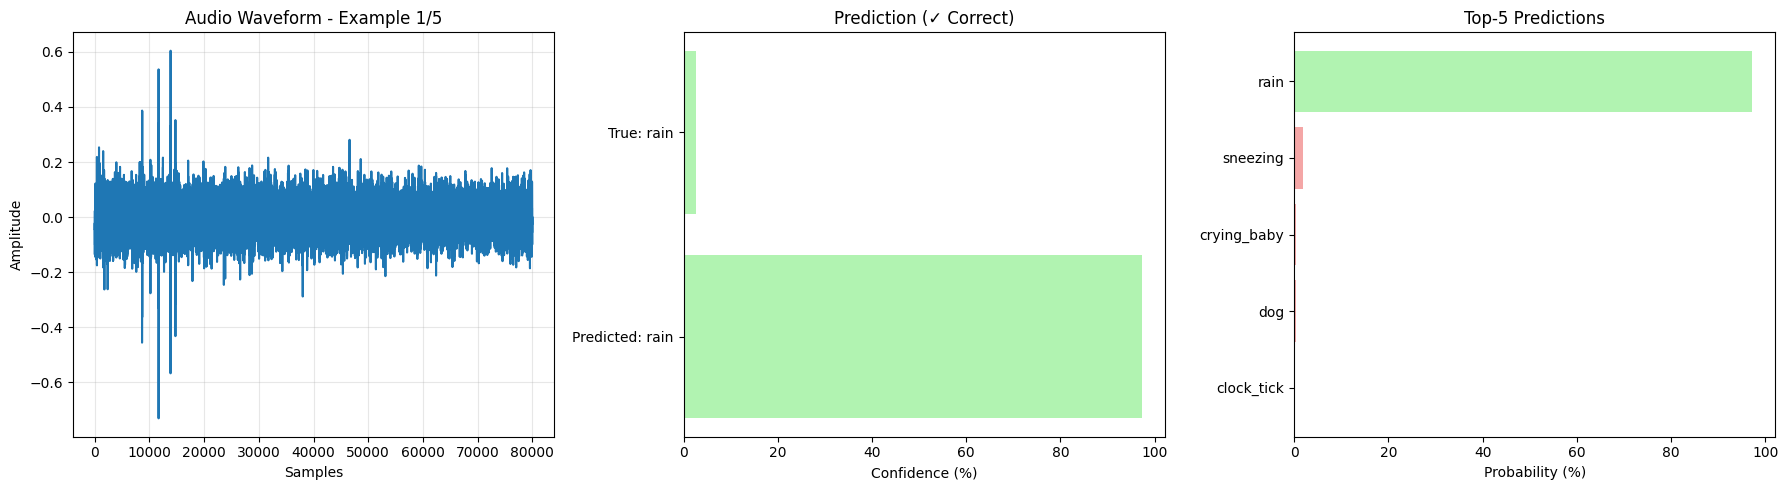

Playing: rain


Prediction: rain (97.27%)
True label: rain
Correct: True


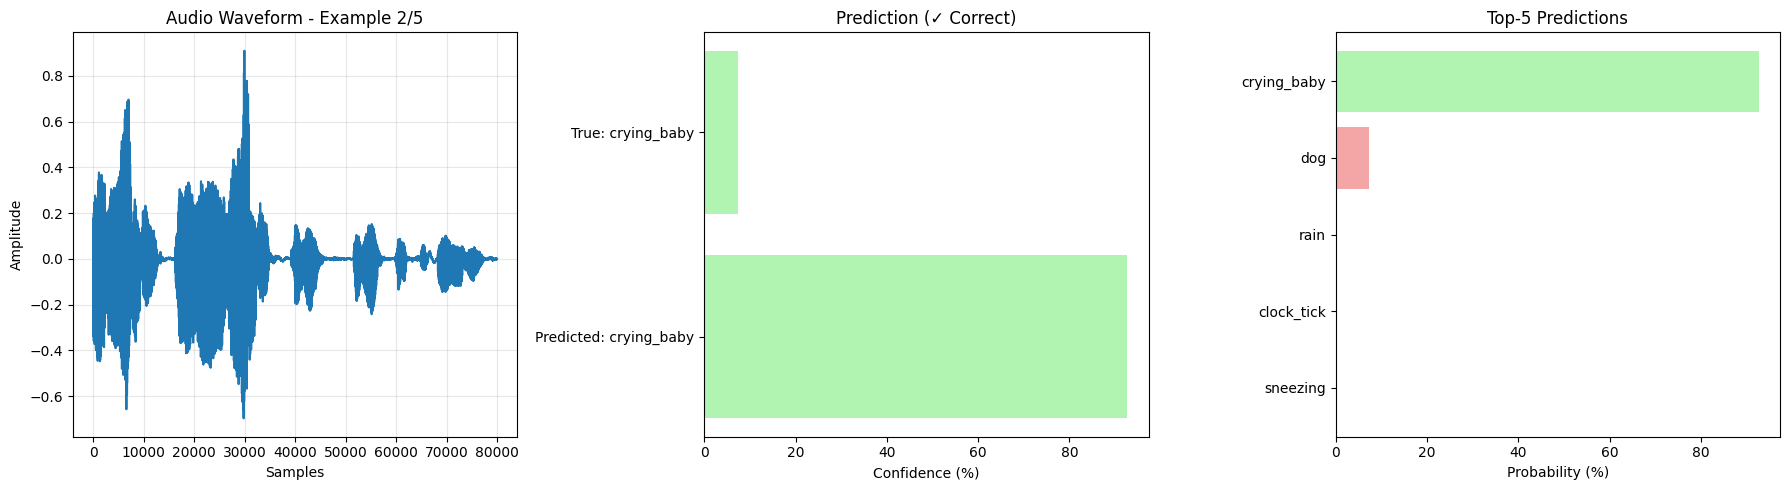

Playing: crying_baby


Prediction: crying_baby (92.71%)
True label: crying_baby
Correct: True


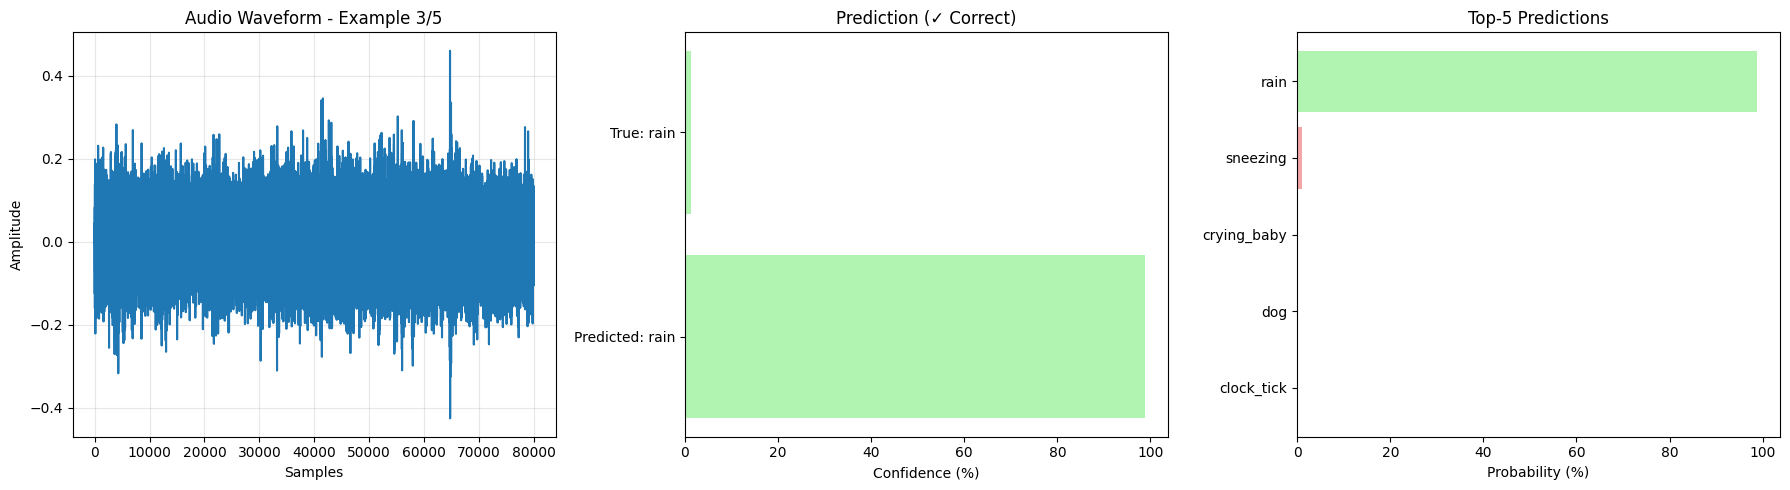

Playing: rain


Prediction: rain (98.79%)
True label: rain
Correct: True


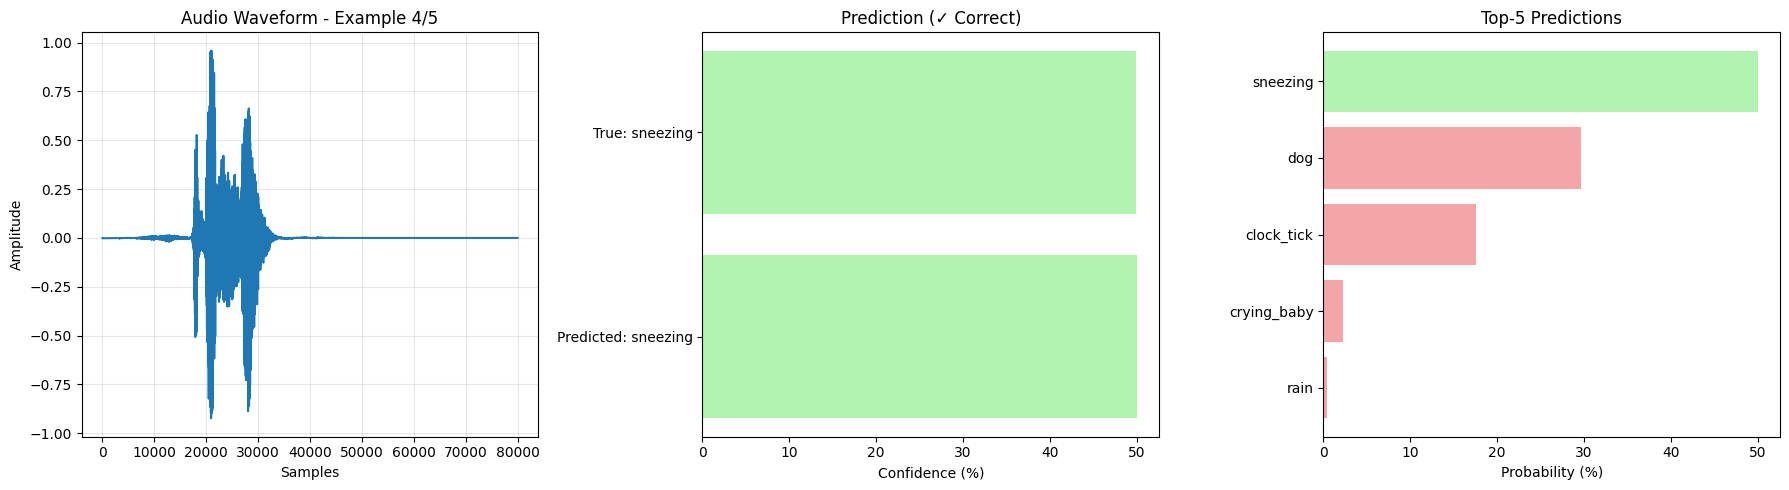

Playing: sneezing


Prediction: sneezing (50.08%)
True label: sneezing
Correct: True


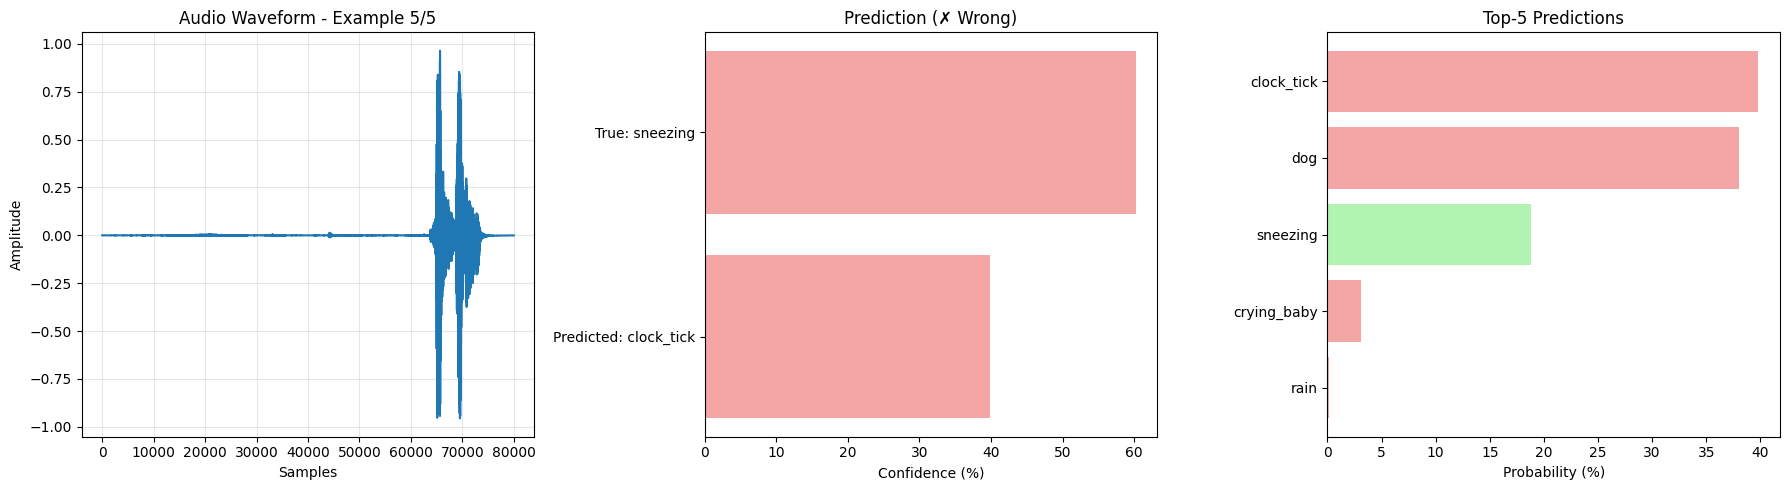

Playing: sneezing


Prediction: clock_tick (39.82%)
True label: sneezing
Correct: False
ESC-50 Test Set Evaluation (Fold 5):
Correct: 33/40
Accuracy: 82.50%


In [151]:
class ESC50TestDemo:
    def __init__(self, model, test_dataset, device):
        self.model = model
        self.test_dataset = test_dataset
        self.device = device
        self.classes = test_dataset.classes
        self.model.eval()  # Set to evaluation mode

    def predict_audio(self, signal):
        """Predict class for a single audio signal"""
        with torch.no_grad():
            signal = signal.unsqueeze(0).to(self.device)  # Add batch dimension
            outputs = self.model(signal)
            probabilities = torch.softmax(outputs, dim=1)
            confidence, predicted = torch.max(probabilities, 1)

        return predicted.item(), confidence.item(), probabilities.cpu().numpy()[0]

    def run_interactive_demo(self, num_examples=1):
        """Run interactive demo with random test examples"""
        print("ESC-50 Audio Classification Demo!")
        print("=" * 60)

        # Get random test examples
        indices = np.random.choice(len(self.test_dataset), num_examples, replace=False)

        for i, idx in enumerate(indices):
            # Load audio and true label
            signal, true_label = self.test_dataset[idx]
            true_class = self.classes[true_label]

            # Get prediction
            predicted_idx, confidence, all_probs = self.predict_audio(signal)
            predicted_class = self.classes[predicted_idx]

            # Clear previous output
            # clear_output(wait=True)

            # Create plot
            fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

            # Plot waveform
            ax1.plot(signal.squeeze().numpy())
            ax1.set_title(f'Audio Waveform - Example {i+1}/{num_examples}')
            ax1.set_xlabel('Samples')
            ax1.set_ylabel('Amplitude')
            ax1.grid(True, alpha=0.3)

            # Plot prediction info
            colors = ['lightcoral', 'lightgreen']
            correct = predicted_class == true_class
            ax2.barh([0, 1], [confidence * 100, (1-confidence) * 100],
                     color=colors[correct], alpha=0.7)
            ax2.set_yticks([0, 1])
            ax2.set_yticklabels([f'Predicted: {predicted_class}',
                               f'True: {true_class}'])
            ax2.set_xlabel('Confidence (%)')
            ax2.set_title(f'Prediction ({"✓ Correct" if correct else "✗ Wrong"})')

            # Plot top-5 predictions
            top5_indices = np.argsort(all_probs)[-5:][::-1]
            top5_classes = [self.classes[idx] for idx in top5_indices]
            top5_probs = all_probs[top5_indices]

            colors = ['lightgreen' if cls == true_class else 'lightcoral' for cls in top5_classes]
            ax3.barh(range(5), top5_probs * 100, color=colors, alpha=0.7)
            ax3.set_yticks(range(5))
            ax3.set_yticklabels(top5_classes)
            ax3.set_xlabel('Probability (%)')
            ax3.set_title('Top-5 Predictions')
            ax3.invert_yaxis()  # Highest probability at top

            plt.tight_layout()
            plt.show()

            # Display audio player
            print(f"Playing: {true_class}")
            display(Audio(signal.squeeze().numpy(), rate=16000))

            print(f"Prediction: {predicted_class} ({confidence:.2%})")
            print(f"True label: {true_class}")
            print(f"Correct: {correct}")
            print("=" * 60)


    def evaluate_test_set(self):
        """Evaluate on entire test set"""
        test_loader = DataLoader(self.test_dataset, batch_size=32, shuffle=False)
        self.model.eval()
        correct = 0
        total = 0
        all_predictions = []
        all_labels = []

        with torch.no_grad():
            for data, target in test_loader:
                data, target = data.to(self.device), target.to(self.device)
                outputs = self.model(data)
                _, predicted = torch.max(outputs.data, 1)

                total += target.size(0)
                correct += (predicted == target).sum().item()

                all_predictions.extend(predicted.cpu().numpy())
                all_labels.extend(target.cpu().numpy())

        accuracy = 100 * correct / total
        print(f"ESC-50 Test Set Evaluation (Fold 5):")
        print(f"Correct: {correct}/{total}")
        print(f"Accuracy: {accuracy:.2f}%")

        return accuracy, all_predictions, all_labels

# Usage
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Create demo
demo = ESC50TestDemo(model, valid_data, device)

# Run interactive demo
demo.run_interactive_demo(num_examples=5)

# Evaluate on entire test set
test_accuracy, predictions, true_labels = demo.evaluate_test_set()

### **Create submission to Stepik**

Вам нужно:
* **1 шаг.** сделать предсказания для `test.csv` при помощи лучшей модели
* **2 шаг.** создать `submission.csv` файл с колонкой `category`, положить туда свои предсказания и сохранить файл.

In [152]:
test_data = SimpleAudioDataset(
    test_df, audio_column="path", label_column=None,
    target_sr=TARGET_SR, duration=DURATION_SEC,
    do_augmentation=False
)

def collate(batch):
    X = torch.stack(batch, dim=0)
    return X

test_loader = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True,
                          collate_fn=collate)

all_preds = []

with torch.no_grad():
    model.eval()
    for batch in test_loader:
        batch = batch.to(device)
        logits = model(batch)
        probs = torch.softmax(logits, dim=1)
        preds = probs.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())

In [153]:
y_test_pred = enc.inverse_transform(all_preds)

In [154]:
submission = pd.read_csv("/content/test.csv")
submission['category'] = y_test_pred
submission.to_csv("/content/submission.csv", index=False)

### **Report**

Было реализовано:
>
> * предобработка аудио (ресемплинг до 16 кГц, перевод в моно, паддинг/обрезку до фиксированной длины, аугментации во временной области);
> * простая архитектура 1D CNN для классификации по сигналу (Conv → BN → ReLU → Global Average Pooling → Linear);
> * базовый цикл обучения с `Adam` и `CrossEntropyLoss`.
>
> Из-за ограниченного времени я провела только базовые запуски:
>
> * при 20 эпохах модель показала accuracy ≈ 0.67;
> * при 100 эпохах — улучшение до ≈ 0.82.
>
> Я не успела подробно поэкспериментировать с архитектурой и гиперпараметрами, однако результаты показали, что даже простая CNN способна обучаться достаточно эффективно.
